In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
from scipy.ndimage import uniform_filter, generic_filter
from scipy.signal import correlate
from tqdm import tqdm
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing
import cv2
from matplotlib.colors import Normalize
from scipy.signal import correlate
from scipy.signal import correlate2d
import math
import pandas as pd
from image_registration import chi2_shift
from image_registration.fft_tools import shift

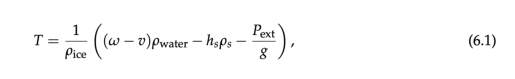

In [10]:
save = "/Users/semita/Desktop/polaris/"
image = plt.imread(save + "equation.png")
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.title("")
plt.show()

In [11]:
# Physical constants (typical values)
rho_ice = 917       # kg/m^3  (sea ice density)
rho_water = 1000    # kg/m^3  (seawater density)
g = 9.81            # m/s^2   (gravitational acceleration)
P_ext = 0           # Pa (external pressure offset — set to 0 if unknown)

In [12]:
def ice_thickness(omega, v, rho_water, rho_ice, h_s, rho_s, P_ext, g):
    """
    Parameters:
        omega (float): Distance from water level to ice underside
        v (float): Vehicle depth
        rho_water (float): Water density
        rho_ice (float): Ice density
        h_s (float): Snow thickness
        rho_s (float): Snow density
        P_ext (float): External pressure offset
        g (float): Gravitational acceleration
    """
    T = (1 / rho_ice) * ((omega - v) * rho_water - h_s * rho_s - P_ext / g)
    return T